In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [2]:
from erddapy import servers
glider_servers = next(server for label, server in servers.items() if "gliders" in server.url)
glider_servers

Server(description='NOAA IOOS NGDAC (National Glider Data Assembly Center)', url='https://gliders.ioos.us/erddap/')

In [3]:
from erddapy import servers
[{label: server.url} for label, server in servers.items()][:5]

[{'voto': 'https://erddap.observations.voiceoftheocean.org/erddap/'},
 {'slgo-ogsl': 'https://erddap.ogsl.ca/erddap/'},
 {'cswc': 'https://coastwatch.pfeg.noaa.gov/erddap/'},
 {'apdrc': 'https://apdrc.soest.hawaii.edu/erddap/'},
 {'ncei': 'https://www.ncei.noaa.gov/erddap/'}]

## Get Datasets for Each Grid

In [4]:
from urllib.error import HTTPError

from erddap_client.erddap_wrapper import GliderIngestor

glider_ingestor = GliderIngestor()

grid_datasets = {}
no_dataset_grids = {}
grid_step_size = 10
for lat in range(0, 60, grid_step_size):
    for lon in range(-180, 180, grid_step_size):
        min_lat = lat
        max_lat = lat + grid_step_size
        min_lon = lon
        max_lon = lon + grid_step_size

        grid_label = f"lat_{min_lat}_{max_lat}_lon_{min_lon}_{max_lon}"

        try:
            grid_datasets[grid_label] = glider_ingestor.dataset_search(
                min_lat=min_lat,
                max_lat=max_lat,
                min_lon=min_lon,
                max_lon=max_lon,
            ).assign(grid_label=grid_label)
        except HTTPError:
            no_dataset_grids[grid_label] = {
                "min_lat": min_lat,
                "max_lat": max_lat,
                "min_lon": min_lon,
                "max_lon": max_lon,
            }

In [5]:
import pandas as pd

glider_datasets = pd.concat(grid_datasets.values(), ignore_index=True).drop_duplicates()
glider_datasets.columns

Index(['griddap', 'Subset', 'tabledap', 'Make A Graph', 'wms', 'files',
       'Title', 'Summary', 'FGDC', 'ISO 19115', 'Info', 'Background Info',
       'RSS', 'Email', 'Institution', 'Dataset ID', 'grid_label'],
      dtype='str')

## Combine datasets with overlapping grid labels

In [6]:
def combine_grid_labels(labels):
    unique_labels = pd.Series(labels).dropna().drop_duplicates()
    return ", ".join(unique_labels)

metadata_columns = [column for column in glider_datasets.columns if column != "grid_label"]
glider_datasets = (
    glider_datasets.groupby("Dataset ID", as_index=False, sort=False)
    .agg({
        **{column: "first" for column in metadata_columns if column != "Dataset ID"},
        "grid_label": combine_grid_labels,
    })
)

glider_datasets = glider_datasets[['Dataset ID','Title','Summary','Institution','grid_label']]
glider_datasets.head()

,Dataset ID,Title,Summary,Institution,grid_label
0,ng616-20180701T0000,ng616-20180701T0000,"AOML's Physical Oceanography Division, the Car...","Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60
1,ng467-20180701T0000,ng467-20180701T0000,This collaborative project is focused on colle...,"Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60
2,ng291-20180701T0000,ng291-20180701T0000,This collaborative project is focused on colle...,"Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60
3,ng222-20200908T1821,ng222-20200908T1821,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_10_20_lon_-70_-60
4,ng231-20190901T0000,ng231-20190901T0000,This Naval Oceanographic Office (NAVOCEANO) Li...,"Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60


## Get Metadata for each dataset

In [7]:
datasets_metadata_list = []

for dataset_title in glider_datasets['Title']:
    df_info = glider_ingestor.get_dataset_metadata(dataset_title)

    df_info['Title'] = dataset_title

    datasets_metadata_list.append(df_info)

datasets_metadata = pd.concat(datasets_metadata_list, ignore_index=True)
datasets_metadata[
    (datasets_metadata['Row Type'] == 'variable')
    & (
        (datasets_metadata['Variable Name'].str.contains('precise_lat'))
        | (datasets_metadata['Variable Name'].str.contains('precise_lon'))
        | (datasets_metadata['Variable Name'] == 'salinity')
        | (datasets_metadata['Variable Name'] == 'temperature')
    )
].head(8)

,Row Type,Variable Name,Attribute Name,Data Type,Value,Title
541,variable,precise_lat,NaN,double,NaN,ng616-20180701T0000
562,variable,precise_lon,NaN,double,NaN,ng616-20180701T0000
944,variable,salinity,NaN,float,NaN,ng616-20180701T0000
1099,variable,temperature,NaN,float,NaN,ng616-20180701T0000
1743,variable,precise_lat,NaN,double,NaN,ng467-20180701T0000
1764,variable,precise_lon,NaN,double,NaN,ng467-20180701T0000
2126,variable,salinity,NaN,float,NaN,ng467-20180701T0000
2281,variable,temperature,NaN,float,NaN,ng467-20180701T0000


## Test Whether all Datasets Have the Same Coordinate Vars

In [8]:
glider_dataset_count = len(datasets_metadata['Title'].unique())

lat_col = 'precise_lat'
lon_col = 'precise_lon'

row_count_for_coords = datasets_metadata[
    (datasets_metadata['Row Type'] == 'variable')
    & 
    (
        datasets_metadata['Variable Name'].str.contains(lat_col) 
        | datasets_metadata['Variable Name'].str.contains(lon_col) 
    ) 
].shape[0]

coord_count_per_row = 2

assert glider_dataset_count, (row_count_for_coords / coord_count_per_row)

## Pull a dataset to test visualization

In [9]:
grid_datasets = glider_datasets[glider_datasets['grid_label'] == 'lat_20_30_lon_-100_-90']
grid_datasets

,Dataset ID,Title,Summary,Institution,grid_label
18,ng450-20180701T0000,ng450-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
22,ng309-20180701T0000,ng309-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
23,ng314-20200806T2040,ng314-20200806T2040,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
26,ng464-20180701T0000,ng464-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
27,ng466-20180701T0000,ng466-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
28,ng489-20180701T0000,ng489-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
29,ng512-20180701T0000,ng512-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
30,ng596-20180701T0000,ng596-20180701T0000,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90
31,ng645-20200730T1909,ng645-20200730T1909,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_20_30_lon_-100_-90


In [12]:
from concurrent.futures import ThreadPoolExecutor

variables = ["precise_lat","precise_lon","salinity","temperature"]

def fetch_glider_rows(dataset_id):
    glider_data = glider_ingestor.get_dataset(dataset_id, variables)
    return glider_data.iloc[1:, :]

dataset_ids = list(grid_datasets['Dataset ID'])
max_workers = min(8, len(dataset_ids)) or 1

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    grid_glider_data_list = list(executor.map(fetch_glider_rows, dataset_ids))

glider_data_df = pd.concat(grid_glider_data_list, ignore_index=True)

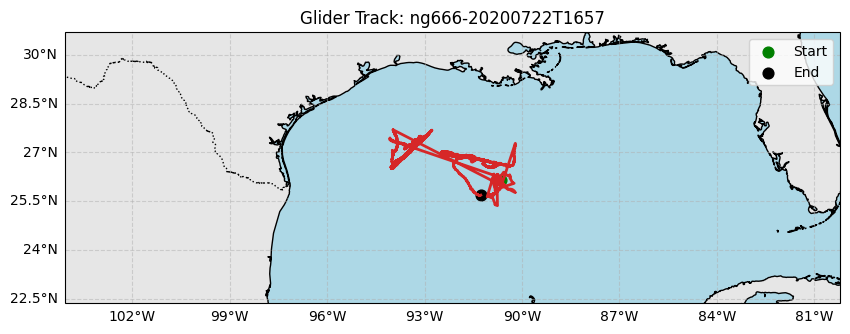

In [14]:
from erddap_client.mapping import make_map_axes
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax, track = make_map_axes(glider_data_df, lon_pad=10, lat_pad=3)

ax.plot(track[lon_col], track[lat_col], color="tab:red", linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(track[lon_col].iloc[0], track[lat_col].iloc[0], color="green", s=60, label="Start", transform=ccrs.PlateCarree())
ax.scatter(track[lon_col].iloc[-1], track[lat_col].iloc[-1], color="black", s=60, label="End", transform=ccrs.PlateCarree())

ax.set_title(f"Glider Track: {dataset_title}")
ax.legend()
plt.show()

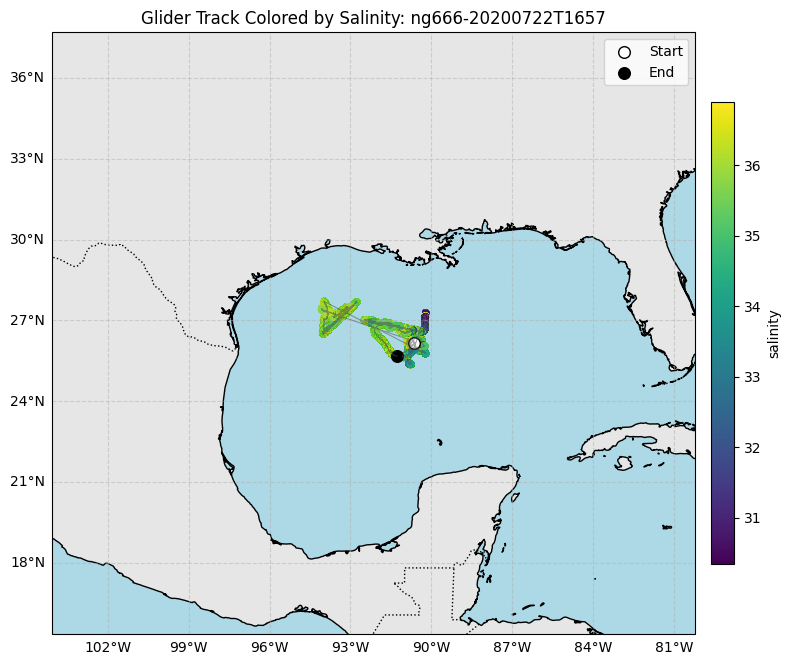

In [15]:
salinity_col = 'salinity'

track_salinity = glider_data_df[[lon_col, lat_col, salinity_col]].copy()

for col in [lon_col, lat_col, salinity_col]:
    track_salinity[col] = pd.to_numeric(track_salinity[col], errors='coerce')

track_salinity = track_salinity.dropna()

fig, ax, _ = make_map_axes(track_salinity, lon_pad=10, lat_pad=10)

scatter = ax.scatter(
    track_salinity[lon_col],
    track_salinity[lat_col],
    c=track_salinity[salinity_col],
    cmap="viridis",
    s=18,
    transform=ccrs.PlateCarree(),
)
ax.plot(track_salinity[lon_col], track_salinity[lat_col], color="0.3", linewidth=0.8, alpha=0.5, transform=ccrs.PlateCarree())
ax.scatter(track_salinity[lon_col].iloc[0], track_salinity[lat_col].iloc[0], color="white", edgecolor="black", s=70, label="Start", transform=ccrs.PlateCarree())
ax.scatter(track_salinity[lon_col].iloc[-1], track_salinity[lat_col].iloc[-1], color="black", s=70, label="End", transform=ccrs.PlateCarree())

colorbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.75)
colorbar.set_label(salinity_col)
ax.set_title(f"Glider Track Colored by Salinity: {dataset_title}")
ax.legend()
plt.show()